# Tutorial 1 — Basic ChemEquivMapper workflow

This notebook demonstrates how to use **ChemEquivMapper** for metabolite identifier harmonization and pathway mapping.

We will run the workflow step by step and inspect how each step changes the mapping results.

The workflow includes:

1. Preprocessing metabolomics feature tables
2. RefMet-based identifier harmonization
3. ChEBI ontology lookup
4. Chemical equivalence mapping using ChEBI relations
5. `is_a` specialization mapping
6. `is_a` generalisation mapping
7. Comparison of mapping coverage before and after ChemEquiv


## 1. Installation and imports


In [ ]:
# Run once in a fresh Google Colab session
%pip install -q git+https://github.com/tiganouri/ChemEquivMapper.git

from pathlib import Path
import subprocess

REPO = Path("/content/ChemEquivMapper")
if not REPO.exists():
    subprocess.run(
        ["git", "clone", "https://github.com/tiganouri/ChemEquivMapper.git", str(REPO)],
        check=True,
    )


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import ChemEquiv

from ChemEquiv.context import PipelineContext
from ChemEquiv.resources import ReactomeTXTConfig, KEGGTSVConfig
from ChemEquiv.preprocess import PreprocessConfig, Preprocessor

from ChemEquiv.steps.step1_refmet.runner import Step1RefMet
from ChemEquiv.steps.step2_chebi.runner import Step2ChebiLookup
from ChemEquiv.steps.step3_ro_reactome.runner import Step3RO
from ChemEquiv.steps.step4_isa_specialization.runner import Step4IsASpecialization
from ChemEquiv.steps.step5_isa_generalisation.runner import Step5IsAGeneralisation

from ChemEquiv.analysis import StepwiseORA

## 2. Select the example dataset

The COVID-19 dataset is used because it consists of a single assay table and
therefore does not require assay merging.

To analyse a different dataset, replace `feature_table_path` and
`metadata_path` with the paths to your own files.

Expected feature-table format:

- the first column contains metabolite or feature names;
- all remaining columns contain sample abundances.

Expected metadata format:

- one row per sample;
- one sample-identifier column;
- one experimental-group column.


In [ ]:
BASE = REPO
feature_table_path = BASE / "experimental_data" / "Covid-19_Su et al..txt"
metadata_path = BASE / "experimental_data" / "metadata_group_Covid-19_Su et al..txt"

assert feature_table_path.exists(), feature_table_path
assert metadata_path.exists(), metadata_path
print(feature_table_path)
print(metadata_path)


/content/ChemEquivMapper/experimental_data/Covid-19_Su et al..txt
/content/ChemEquivMapper/experimental_data/metadata_group_Covid-19_Su et al..txt


### Optional: use uploaded files in Colab


In [ ]:
# Uncomment in Google Colab to upload your own two files.
# from google.colab import files
# uploaded = files.upload()
# feature_table_path = Path("my_feature_table.tsv")
# metadata_path = Path("my_metadata.tsv")


## 3. Inspect and organise the input


In [ ]:
from pathlib import Path
import pandas as pd


def read_tabular_file(path, sep="\t"):
    """
    Read a tabular text file using common encodings.

    Parameters
    ----------
    path : str or Path
        Path to the input file.
    sep : str
        Column separator. Default is tab.

    Returns
    -------
    pandas.DataFrame
        Imported table.
    """
    path = Path(path)

    encodings = [
        "utf-8",
        "utf-8-sig",
        "utf-16",
        "utf-16-le",
        "utf-16-be",
        "latin-1",
    ]

    errors = []

    for encoding in encodings:
        try:
            df = pd.read_csv(
                path,
                sep=sep,
                encoding=encoding,
            )

            print(
                f"Loaded '{path.name}' using encoding='{encoding}' "
                f"with shape {df.shape}"
            )

            return df

        except (UnicodeDecodeError, UnicodeError) as exc:
            errors.append(f"{encoding}: {exc}")

    raise UnicodeError(
        f"Could not decode '{path}'. Tried: {encodings}\n"
        + "\n".join(errors)
    )

In [ ]:
exp_raw = read_tabular_file(feature_table_path)
meta_raw = read_tabular_file(metadata_path)

print("\nFeature table shape:", exp_raw.shape)
print("Metadata shape:", meta_raw.shape)

display(exp_raw.head())
display(meta_raw.head())

Loaded 'Covid-19_Su et al..txt' using encoding='utf-8' with shape (1050, 388)
Loaded 'metadata_group_Covid-19_Su et al..txt' using encoding='utf-16' with shape (387, 2)

Feature table shape: (1050, 388)
Metadata shape: (387, 2)


,sample_id,1004596,1008097,1008631,1012545,1022407,1027537,1054953,1056512,1057494,...,INCOV135-AC,INCOV135-BL,INCOV136-AC,INCOV136-BL,INCOV137-AC,INCOV137-BL,INCOV139-AC,INCOV139-BL,INCOV142-AC,INCOV142-BL
0,S-1-pyrroline-5-carboxylate,0.780685,NaN,1.093995,0.603869,0.699325,1.143618,0.587341,0.481278,1.357455,...,0.950958,0.209067,NaN,0.723258,1.167627,1.064520,2.187221,1.682527,0.823931,0.669127
1,spermidine,1.914103,0.722351,0.410542,0.977809,1.087672,0.449193,3.000837,0.742709,0.299623,...,1.083469,1.023370,3.269244,2.292971,1.876515,1.608219,1.324531,3.975026,1.763974,3.854680
2,1-methylnicotinamide,0.874071,1.302361,0.628660,2.513620,1.532138,1.788824,1.779762,0.481610,0.444545,...,0.895651,2.515001,0.561425,0.650270,1.144925,1.162249,0.336255,0.461765,0.349077,1.596398
3,"12,13-DiHOME",1.626477,0.346423,0.884411,2.872909,0.571260,0.975184,0.849998,0.598554,1.624032,...,NaN,NaN,0.372184,NaN,0.398677,NaN,2.995724,3.031450,0.230712,NaN
4,5-hydroxyindoleacetate,NaN,0.675949,NaN,NaN,NaN,NaN,0.727579,0.442681,1.760987,...,NaN,NaN,NaN,NaN,3.174905,NaN,4.158863,3.421115,NaN,NaN


,sample_id,group
0,1004596,Healthy Donor
1,1008097,Healthy Donor
2,1008631,Healthy Donor
3,1012545,Healthy Donor
4,1022407,Healthy Donor


### Identify metadata columns

The code first looks for common sample and group column names. If the inferred
columns are incorrect for a new dataset, set `sample_col` and `group_col`
manually.


In [ ]:
sample_candidates = [
    "sample", "Sample", "SampleID", "sample_id",
    "sample_name", "run", "Run"
]

sample_col = next(
    (column for column in sample_candidates if column in meta_raw.columns),
    meta_raw.columns[0],
)

group_candidates = [
    "group", "Group", "condition", "Condition",
    "phenotype", "Phenotype", "class", "Class"
]

group_col = next(
    (
        column
        for column in group_candidates
        if column in meta_raw.columns and column != sample_col
    ),
    next(column for column in meta_raw.columns if column != sample_col),
)

meta_df = meta_raw[[sample_col, group_col]].copy()
meta_df[sample_col] = meta_df[sample_col].astype(str).str.strip()
meta_df[group_col] = meta_df[group_col].astype(str).str.strip()

meta_df = (
    meta_df
    .dropna(subset=[sample_col])
    .drop_duplicates(subset=[sample_col])
    .set_index(sample_col)
)

print("Sample column:", sample_col)
print("Group column :", group_col)
print("\nGroup counts:")
display(meta_df[group_col].value_counts(dropna=False))

Sample column: sample_id
Group column : group

Group counts:


,count
group,
COVID19,254
Healthy Donor,133


### Check sample overlap

Only samples present in both the feature table and metadata are retained.
This prevents accidental mismatches between abundance columns and metadata
rows.


In [ ]:
feature_col = exp_raw.columns[0]

feature_samples = [str(column).strip() for column in exp_raw.columns[1:]]
metadata_samples = meta_df.index.astype(str).tolist()

common_samples = [
    sample for sample in metadata_samples
    if sample in feature_samples
]

missing_from_feature_table = [
    sample for sample in metadata_samples
    if sample not in feature_samples
]

extra_feature_columns = [
    sample for sample in feature_samples
    if sample not in metadata_samples
]

print("Samples in metadata       :", len(metadata_samples))
print("Samples in feature table  :", len(feature_samples))
print("Matched samples           :", len(common_samples))
print("Missing from feature table:", len(missing_from_feature_table))
print("Extra feature columns     :", len(extra_feature_columns))

if not common_samples:
    raise ValueError(
        "No sample identifiers overlap between the feature table and metadata."
    )


Samples in metadata       : 387
Samples in feature table  : 387
Matched samples           : 387
Missing from feature table: 0
Extra feature columns     : 0


## 4. Step 0 — clean metabolite names


In [ ]:
import re
from pathlib import Path
import pandas as pd
import numpy as np

suffix_pat_digit = re.compile(r"\s*((\[\d\]|\(\d\))\*?|\*)\s*$")
suffix_pat_nh4 = re.compile(r"\s*\[M\+NH4\]\+\s*$", flags=re.IGNORECASE)
suffix_pat_plasmalogen = re.compile(r"\s*plasmalogen\s*$", flags=re.IGNORECASE)
suffix_pat_isomer = re.compile(r"\s*-isomer\d+\s*$", flags=re.IGNORECASE)

SUFFIX_PATS = [
    suffix_pat_nh4,
    suffix_pat_plasmalogen,
    suffix_pat_isomer,
    suffix_pat_digit,
]

def clean_feature_name(s: str) -> str:
    s = str(s).strip()

    for _ in range(5):
        before = s
        for pat in SUFFIX_PATS:
            s = pat.sub("", s).strip()

        if s == before:
            break

    return s


In [ ]:
OUTDIR = Path("/content/ChemEquivMapper_tutorial_1_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

exp_df = exp_raw[[feature_col] + common_samples].copy()

before = exp_df[feature_col].astype(str)
after = before.map(clean_feature_name)
exp_df[feature_col] = after

name_changes = pd.DataFrame({"before": before, "after": after})
name_changes = name_changes[name_changes["before"] != name_changes["after"]]
print(f"Names changed: {len(name_changes):,}")
display(name_changes.head(10))


Names changed: 322


,before,after
120,N-stearoyl-sphinganine (d18:0/18:0)*,N-stearoyl-sphinganine (d18:0/18:0)
185,N-stearoyl-sphingosine (d18:1/18:0)*,N-stearoyl-sphingosine (d18:1/18:0)
314,"bradykinin, hydroxy-pro(3)","bradykinin, hydroxy-pro"
335,"bradykinin, des-arg(9)","bradykinin, des-arg"
347,erythronate*,erythronate
348,Fibrinopeptide A*,Fibrinopeptide A
349,"Fibrinopeptide A, des-ala(1)*","Fibrinopeptide A, des-ala"
350,salicyluric glucuronide*,salicyluric glucuronide
356,metoprolol acid metabolite*,metoprolol acid metabolite
377,3-(3-amino-3-carboxypropyl)uridine*,3-(3-amino-3-carboxypropyl)uridine


## Configure the preprocessing workflow

Here we define the preprocessing parameters used throughout this tutorial.

These settings are identical for all experimental datasets.

In [ ]:
import sys
from pathlib import Path

REPO = Path("/content/ChemEquivMapper")

if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from exp_data_preprocessing import exp_preprocessing as ep

# Preprocessing configuration
cfg = ep.DatasetPreprocessConfig(
    # Remove metabolites with more than 30% missing values
    max_missing_frac=0.30,

    # Remove blank samples, when available
    drop_blanks=True,

    # KNN imputation
    knn_k=5,
    knn_weights="distance",

    # Label for samples without group information
    na_group_label="NA",

    # Fallback imputation
    fallback_divisor=1000,
    fallback_when_knn_fails=True,
    fallback_when_nans_remain=True,
)

# Log transformation and PCA configuration
log_cfg = ep.LogTransformConfig(
    log_mode="log10",
    log_offset=1e-9,

    # PCA comparison: raw versus log-transformed data
    pca_compare_out_dir=Path("tutorial_outputs/pca_plots"),
    pca_n_components=3,
    pca_prefix="PCA_COMPARE",

    # PCA loadings
    pca_loadings_out_dir=Path("tutorial_outputs/pca_loadings"),
    pca_loadings_prefix="PCA_LOADINGS",
)

pp = ep.DatasetPreprocessor(
    cfg=cfg,
    log_cfg=log_cfg,
)

print("Experimental-data preprocessor created.")

Experimental-data preprocessor created.


In [ ]:
BASE = Path("/content/ChemEquivMapper")

selected_ds_paths = {
    "ds1_COVID": BASE / "experimental_data" / "Covid-19_Su et al..txt",
}

selected_group_paths = {
    "grp1_COVID": BASE / "experimental_data" / "metadata_group_Covid-19_Su et al..txt",
}

selected_ds_to_meta = {
    "ds1_COVID": "grp1_COVID",
}

selected_groups_of_interest = {
    "grp1_COVID": ["Healthy Donor", "COVID19"],
}

In [ ]:
datasets = pp.build_preprocessed_datasets(
    ds_paths=selected_ds_paths,
    group_paths=selected_group_paths,
    ds_to_meta=selected_ds_to_meta,
    groups_of_interest=selected_groups_of_interest,
)

print(f"{len(datasets)} dataset successfully preprocessed.")
print(list(datasets.keys()))

1 dataset successfully preprocessed.
['ds1_COVID']


In [ ]:
example_study = "ds1_COVID"

for k, v in datasets[example_study].items():
    if hasattr(v, "shape"):
        print(f"{k:20s} {type(v).__name__:15s} shape={v.shape}")
    else:
        print(f"{k:20s} {type(v).__name__}")

paths                dict
groups_keep          list
feature_col          str
raw_df               DataFrame       shape=(1050, 388)
raw_meta             DataFrame       shape=(387, 2)
df_raw               DataFrame       shape=(873, 388)
df_log               DataFrame       shape=(873, 388)
meta                 DataFrame       shape=(387, 1)
report_align         dict
report_blanks        dict
report_sparse_rows   dict
log_cfg              dict
feature_meta         DataFrame       shape=(873, 2)
metabolite_feature_map DataFrame       shape=(864, 2)
pca_compare_plot     str
pca_loadings_csv     str


## PCA comparison before and after preprocessing

The preprocessing step automatically generates PCA comparison plots for each dataset.

Each plot shows the sample distribution before and after or log transformation. These plots are useful for checking whether preprocessing improves the structure and separation of the biological groups.

Found 1 PCA comparison plots:


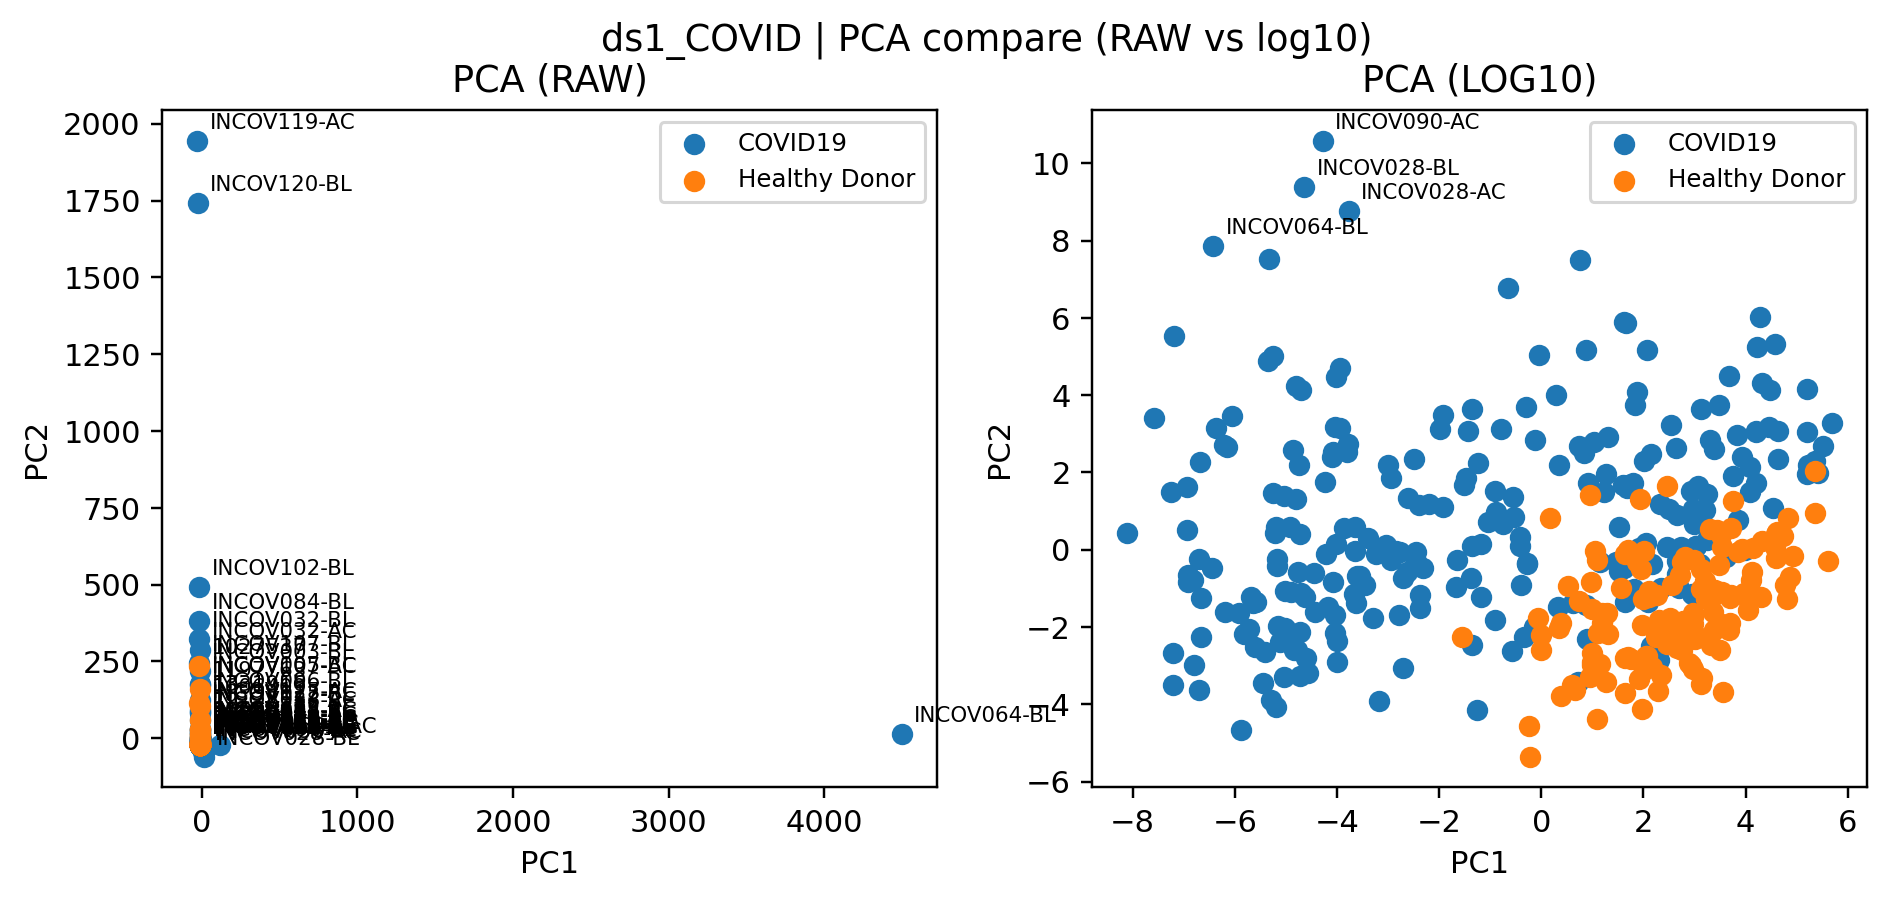

In [ ]:
from pathlib import Path
from IPython.display import Image, display

pca_dir = Path("tutorial_outputs/pca_plots")

pca_files = sorted(pca_dir.glob("PCA_COMPARE*.png"))

print(f"Found {len(pca_files)} PCA comparison plots:")
for f in pca_files:
    display(Image(filename=str(f)))

## 5. ChemEquivMapper preprocessing

ChemEquivMapper preprocessing converts the feature table and metadata into the
tables required by the identifier-mapping steps.

This is distinct from the statistical preprocessing, PCA and differential
abundance workflow presented in Tutorial 2.

In [ ]:
selected_preprocessed = datasets[example_study]

# Use the log-transformed and imputed abundance matrix
exp_df = selected_preprocessed["df_log"].copy()

# The first column contains the unique feature identifiers
feature_col = exp_df.columns[0]

# Remove uniqueness suffixes such as __1, __2, ...
exp_df[feature_col] = (
    exp_df[feature_col]
    .astype(str)
    .str.replace(r"__\d+$", "", regex=True)
)

OUTDIR = Path("tutorial_preprocess")
OUTDIR.mkdir(parents=True, exist_ok=True)

feature_table_path = OUTDIR / f"{example_study}__df_log.csv"

exp_df.to_csv(
    feature_table_path,
    index=False,
)

print("Feature table used for ChemEquivMapper:")
print(feature_table_path)
print("Shape:", exp_df.shape)

display(exp_df.head())

Feature table used for ChemEquivMapper:
tutorial_preprocess/ds1_COVID__df_log.csv
Shape: (873, 388)


,sample_id,1004596,1008097,1008631,1012545,1022407,1027537,1054953,1056512,1057494,...,INCOV135-AC,INCOV135-BL,INCOV136-AC,INCOV136-BL,INCOV137-AC,INCOV137-BL,INCOV139-AC,INCOV139-BL,INCOV142-AC,INCOV142-BL
0,S-1-pyrroline-5-carboxylate,-0.107524,-0.065298,0.039015,-0.219057,-0.155321,0.058281,-0.231110,-0.317604,0.132725,...,-0.021839,-0.679715,-0.161198,-0.140707,0.067304,0.027154,0.339893,0.225962,-0.084109,-0.174492
1,spermidine,0.281965,-0.141252,-0.386642,-0.009746,0.036498,-0.347567,0.477242,-0.129181,-0.523424,...,0.034817,0.010033,0.514447,0.360399,0.273352,0.206345,0.122062,0.599340,0.246492,0.585988
2,1-methylnicotinamide,-0.058453,0.114731,-0.201584,0.400300,0.185298,0.252568,0.250362,-0.317304,-0.352084,...,-0.047861,0.400538,-0.250708,-0.186906,0.058777,0.065299,-0.473331,-0.335579,-0.457079,0.203141
3,"12,13-DiHOME",0.211248,-0.460393,-0.053346,0.458322,-0.243166,-0.010914,-0.070582,-0.222897,0.210595,...,0.548583,-0.004757,-0.429242,-0.396088,-0.399378,-0.043922,0.476502,0.481650,-0.636931,-0.336357
5,alpha-ketoglutarate,0.005499,0.040879,-0.076807,-0.028713,0.090562,0.053636,-0.107148,-0.197770,-0.029987,...,0.015374,0.006408,0.092326,-0.136570,-0.190860,-0.273678,0.135385,0.116895,0.047861,-0.222273


In [ ]:
prep_cfg = PreprocessConfig(
    feature_col=None,
    test="ttest",
    ratio_thresh=10.0,
    alpha=0.05,
    min_n_per_group=2,
)

prep = Preprocessor(prep_cfg)

result = prep.run(
    feature_table_path=str(feature_table_path),
    sample_meta=selected_preprocessed["meta"],
    group_col=group_col,
)

print("Available preprocessing outputs:")
print(vars(result).keys())

print("\nUnique experimental features:", len(result.feature_meta))
print("Metabolite-statistics rows   :", len(result.metabolite_stats))

display(result.metabolite_stats.head())



[Preprocess] Duplicate canonical names detected (kept):
  - 'bilirubin' at rows: [133, 414, 415, 863, 864, 865, 866, 867, 868, 869]
[Preprocess] End duplicate report.

Available preprocessing outputs:
dict_keys(['abundance_feature', 'feature_meta', 'metabolite_stats', 'scale_report', 'metabolite_feature_map'])

Unique experimental features: 873
Metabolite-statistics rows   : 864


,metabolite_id,p_value,method_used,n_features,n_per_group,p_adj,significant
0,cysteine s-sulfate,5.960685e-69,single,1,"Healthy Donor:133,COVID19:254",5.150032e-66,True
1,levulinate (4-oxovalerate),7.307009e-68,single,1,"Healthy Donor:133,COVID19:254",3.156628e-65,True
2,inosine,1.048500e-63,single,1,"Healthy Donor:133,COVID19:254",3.019681e-61,True
3,beta-citrylglutamate,2.536474e-57,single,1,"Healthy Donor:133,COVID19:254",5.478783e-55,True
4,N-acetylneuraminate,3.615222e-57,single,1,"Healthy Donor:133,COVID19:254",6.247103e-55,True


In [ ]:
result.abundance_feature.to_csv(
    OUTDIR / "abundance_feature.csv"
)
result.feature_meta.to_csv(
    OUTDIR / "feature_meta.csv",
    index=False,
)
result.metabolite_stats.to_csv(
    OUTDIR / "metabolite_stats.csv",
    index=False,
)


## 6. Load pathway and ontology resources


In [ ]:
PKG_ROOT = REPO

reactome_txt = ( PKG_ROOT / "src" / "ChemEquiv"/ "data" / "reactome" / "ChEBI2Reactome.txt")

kegg_tsv = ( PKG_ROOT / "src" / "ChemEquiv" / "data" / "kegg" / "kegg_compound_to_pathway.tsv")

chebi_obo = ( PKG_ROOT / "src" / "ChemEquiv" / "data" / "chebi" / "chebi.obo.gz")

ctx = PipelineContext(repo_root=PKG_ROOT).load_resources_default(
    reactome_cfg=ReactomeTXTConfig(
        source="local",
        local_txt_path=reactome_txt,
    ),
    kegg_cfg=KEGGTSVConfig(
        source="download",
        local_tsv_path=kegg_tsv,
    ),
    species="Homo sapiens",
)

step1 = Step1RefMet(repo_root=PKG_ROOT)

## 7. Step 1 — RefMet harmonisation


In [ ]:
meta_for_step1 = result.metabolite_stats.copy()

df_step1 = step1.run(
    meta_for_step1,
    ctx=ctx,
    unzip=True,
    map_pathways=True,
    output_csv=None,
)

step1_path = OUTDIR / "step1_refmet.tsv"
df_step1.to_csv(step1_path, sep="\t", index=False)

print("Step 1 completed.")
print(df_step1.shape)

display(df_step1.head())


Step 1 completed.
(864, 19)


,Input name,RefMet_ID,Formula,Exact mass,Super class,Main class,Sub class,PubChem_CID,ChEBI_ID,HMDB_ID,LM_ID,KEGG_ID,INCHI_KEY,SMILES,Standardized name,ChEBI_ID_Step1_reactome,Reactome_Pathways_Step1,KEGG_Compounds_Step1,KEGG_Pathways_Step1
0,cysteine s-sulfate,RM0041317,C3H7NO5S2,200.9766,Organic acids,Amino acids and peptides,Amino acids,115015,CHEBI:27891,HMDB0000731,NaN,C05824,NOKPBJYHPHHWAN-REOHCLBHSA-N,C([C@@H](C(=O)O)N)SS(=O)(=O)O,Cysteine-S-sulfate,,,C05824,"map01100,map01230,map00270"
1,levulinate (4-oxovalerate),RM0152340,C5H8O3,116.0473,Fatty Acyls,Fatty acids,Oxo FA,11579,CHEBI:45630,HMDB0000720,LMFA01060006,NaN,JOOXCMJARBKPKM-UHFFFAOYSA-N,CC(=O)CCC(=O)O,Levulinic acid,,,,
2,inosine,RM0135908,C10H12N4O5,268.0808,Nucleic acids,Purines,Purine ribonucleosides,135398641,CHEBI:17596,HMDB0000195,NaN,C00294,UGQMRVRMYYASKQ-KQYNXXCUSA-N,C([C@@H]1[C@H]([C@H]([C@H](n2cnc3c2ncnc3O)O1)O...,Inosine,CHEBI:17596,"R-HSA-2161541,R-HSA-5619063,R-HSA-5683826,R-HS...",C00294,"map01100,map01232,map00230,map02010"
3,beta-citrylglutamate,RM0132229,C11H15NO10,321.0696,Organic acids,Amino acids and peptides,Amino acids,21125622,CHEBI:77065,HMDB0013220,NaN,C20775,GAQNUGISBQJMKO-UHFFFAOYSA-N,C(CC(=O)O)C(C(=O)O)NC(=O)C(CC(=O)O)(CC(=O)O)O,Beta-Citryl-glutamic acid,,,C20775,"map01100,map00250"
4,N-acetylneuraminate,RM0135920,C11H19NO9,309.1060,Carbohydrates,Monosaccharides,Sugar acids,445063,CHEBI:17012,HMDB0000230,NaN,C19910,SQVRNKJHWKZAKO-PFQGKNLYSA-N,CC(=O)N[C@@H]1[C@H](C[C@](C(=O)O)(O)O[C@H]1[C@...,N-Acetylneuraminic acid,CHEBI:17012,R-HSA-975577,,


## 8. Step 2 — ChEBI ontology lookup


In [ ]:
from ChemEquiv.resources.chebi_resource_manager import ChebiResourceConfig

step2 = Step2ChebiLookup(
    repo_root=PKG_ROOT,
    chebi_cfg=ChebiResourceConfig(source="local", local_obo_gz_path=chebi_obo),
)
df_step2, chebi_to_kegg, onto = step2.run(df_step1, ctx=ctx)
df_step2.to_csv(OUTDIR / "step2_chebi.tsv", sep="\t", index=False)
display(df_step2.head())

ChEBI OBO exists: True
/content/ChemEquivMapper/src/ChemEquiv/data/chebi/chebi.obo.gz


/usr/local/lib/python3.12/dist-packages/ChemEquiv/steps/step2_chebi/runner.py:146: UnicodeWarning: unsound encoding, assuming Windows-1252 (73% confidence)
  self._onto = pronto.Ontology(str(self._obo_path))


,Input name,RefMet_ID,Formula,Exact mass,Super class,Main class,Sub class,PubChem_CID,ChEBI_ID,HMDB_ID,...,CHEBI_From_Names_All,CHEBI_ID_Step2,KEGG_Exact_From_Names,KEGG_Fuzzy_From_Names,KEGG_From_Names_All,KEGG_ID_Step2,ChEBI_ID_Step2_reactome,Reactome_Pathways_Step2,KEGG_Compounds_Step2,KEGG_Pathways_Step2
0,cysteine s-sulfate,RM0041317,C3H7NO5S2,200.9766,Organic acids,Amino acids and peptides,Amino acids,115015,CHEBI:27891,HMDB0000731,...,CHEBI:27891,CHEBI:27891,C05824,C05824,C05824,C05824,,,C05824,"map01100,map01230,map00270"
1,levulinate (4-oxovalerate),RM0152340,C5H8O3,116.0473,Fatty Acyls,Fatty acids,Oxo FA,11579,CHEBI:45630,HMDB0000720,...,CHEBI:45630,CHEBI:45630,,,,,,,,
2,inosine,RM0135908,C10H12N4O5,268.0808,Nucleic acids,Purines,Purine ribonucleosides,135398641,CHEBI:17596,HMDB0000195,...,"CHEBI:17596,CHEBI:17596,CHEBI:17596",CHEBI:17596,C00294,C00294,C00294,C00294,CHEBI:17596,"R-HSA-2161541,R-HSA-5619063,R-HSA-5683826,R-HS...",C00294,"map01100,map01232,map00230,map02010"
3,beta-citrylglutamate,RM0132229,C11H15NO10,321.0696,Organic acids,Amino acids and peptides,Amino acids,21125622,CHEBI:77065,HMDB0013220,...,CHEBI:76942,"CHEBI:76942,CHEBI:77065",C20775,C20775,C20775,C20775,,,C20775,"map01100,map00250"
4,N-acetylneuraminate,RM0135920,C11H19NO9,309.1060,Carbohydrates,Monosaccharides,Sugar acids,445063,CHEBI:17012,HMDB0000230,...,"CHEBI:17012,CHEBI:17012,CHEBI:173082,CHEBI:173...","CHEBI:17012,CHEBI:21619,CHEBI:35418,CHEBI:1730...","C00270,C19910","C00270,C19910","C00270,C19910","C00270,C19910","CHEBI:17012,CHEBI:35418","R-HSA-975577,R-HSA-4085001,R-HSA-428643,R-HSA-...",C00270,"map01100,map01250,map00541"


## 9. Step 3 — RO chemical equivalence


In [ ]:
step3 = Step3RO(repo_root=PKG_ROOT)

step3.set_shared_resources(
    onto=onto,
    chebi_to_kegg=chebi_to_kegg,
)

df_step3 = step3.run(
    df_step2,
    chebi_col_step2="CHEBI_ID_Step2",
    kegg_col_step2="KEGG_ID_Step2",
    ctx=ctx,
)

step3_path = OUTDIR / "step3_ro.tsv"
df_step3.to_csv(step3_path, sep="\t", index=False)

print("Step 3 completed.")
print(df_step3.shape)

display(df_step3.head())


Step 3 completed.
(864, 38)


,Input name,RefMet_ID,Formula,Exact mass,Super class,Main class,Sub class,PubChem_CID,ChEBI_ID,HMDB_ID,...,Reactome_Pathways_Step2,KEGG_Compounds_Step2,KEGG_Pathways_Step2,CHEBI_RO_Equivalents,CHEBI_ID_Step3,KEGG_ID_Step3,ChEBI_ID_Step3_reactome,Reactome_Pathways_Step3,KEGG_Compounds_Step3,KEGG_Pathways_Step3
0,cysteine s-sulfate,RM0041317,C3H7NO5S2,200.9766,Organic acids,Amino acids and peptides,Amino acids,115015,CHEBI:27891,HMDB0000731,...,,C05824,"map01100,map01230,map00270",CHEBI:62225,"CHEBI:27891,CHEBI:62225",C05824,,,C05824,"map01100,map01230,map00270"
1,levulinate (4-oxovalerate),RM0152340,C5H8O3,116.0473,Fatty Acyls,Fatty acids,Oxo FA,11579,CHEBI:45630,HMDB0000720,...,,,,CHEBI:39150,"CHEBI:39150,CHEBI:45630",,,,,
2,inosine,RM0135908,C10H12N4O5,268.0808,Nucleic acids,Purines,Purine ribonucleosides,135398641,CHEBI:17596,HMDB0000195,...,"R-HSA-2161541,R-HSA-5619063,R-HSA-5683826,R-HS...",C00294,"map01100,map01232,map00230,map02010",,CHEBI:17596,C00294,CHEBI:17596,"R-HSA-2161541,R-HSA-5619063,R-HSA-5683826,R-HS...",C00294,"map01100,map01232,map00230,map02010"
3,beta-citrylglutamate,RM0132229,C11H15NO10,321.0696,Organic acids,Amino acids and peptides,Amino acids,21125622,CHEBI:77065,HMDB0013220,...,,C20775,"map01100,map00250",,"CHEBI:76942,CHEBI:77065",C20775,,,C20775,"map01100,map00250"
4,N-acetylneuraminate,RM0135920,C11H19NO9,309.1060,Carbohydrates,Monosaccharides,Sugar acids,445063,CHEBI:17012,HMDB0000230,...,"R-HSA-975577,R-HSA-4085001,R-HSA-428643,R-HSA-...",C00270,"map01100,map01250,map00541",,"CHEBI:17012,CHEBI:21619,CHEBI:35418,CHEBI:1730...","C00270,C19910","CHEBI:17012,CHEBI:35418","R-HSA-975577,R-HSA-4085001,R-HSA-428643,R-HSA-...",C00270,"map01100,map01250,map00541"


## 10. Step 4 — `is_a` specialisation


In [ ]:
step4 = Step4IsASpecialization(
    repo_root=PKG_ROOT,
    max_is_a_depth=1,
    max_equiv_depth=20,
)

step4.set_shared_resources(
    onto=onto,
    chebi_to_kegg=chebi_to_kegg,
)

df_step4 = step4.run(
    df_step3,
    chebi_col_step3="CHEBI_ID_Step3",
    kegg_col_step3="KEGG_ID_Step3",
    ctx=ctx,
)

step4_path = OUTDIR / "step4_isa.tsv"
df_step4.to_csv(step4_path, sep="\t", index=False)

print("Step 4 completed.")
print(df_step4.shape)

display(df_step4.head())


Step 4 completed.
(864, 45)


,Input name,RefMet_ID,Formula,Exact mass,Super class,Main class,Sub class,PubChem_CID,ChEBI_ID,HMDB_ID,...,Reactome_Pathways_Step3,KEGG_Compounds_Step3,KEGG_Pathways_Step3,CHEBI_is_a_Equivalents,CHEBI_ID_Step4,KEGG_ID_Step4,ChEBI_ID_Step4_reactome,Reactome_Pathways_Step4,KEGG_Compounds_Step4,KEGG_Pathways_Step4
0,cysteine s-sulfate,RM0041317,C3H7NO5S2,200.9766,Organic acids,Amino acids and peptides,Amino acids,115015,CHEBI:27891,HMDB0000731,...,,C05824,"map01100,map01230,map00270",,"CHEBI:27891,CHEBI:62225",C05824,,,C05824,"map01100,map01230,map00270"
1,levulinate (4-oxovalerate),RM0152340,C5H8O3,116.0473,Fatty Acyls,Fatty acids,Oxo FA,11579,CHEBI:45630,HMDB0000720,...,,,,,"CHEBI:39150,CHEBI:45630",,,,,
2,inosine,RM0135908,C10H12N4O5,268.0808,Nucleic acids,Purines,Purine ribonucleosides,135398641,CHEBI:17596,HMDB0000195,...,"R-HSA-2161541,R-HSA-5619063,R-HSA-5683826,R-HS...",C00294,"map01100,map01232,map00230,map02010",,CHEBI:17596,C00294,CHEBI:17596,"R-HSA-2161541,R-HSA-5619063,R-HSA-5683826,R-HS...",C00294,"map01100,map01232,map00230,map02010"
3,beta-citrylglutamate,RM0132229,C11H15NO10,321.0696,Organic acids,Amino acids and peptides,Amino acids,21125622,CHEBI:77065,HMDB0013220,...,,C20775,"map01100,map00250",,"CHEBI:76942,CHEBI:77065",C20775,,,C20775,"map01100,map00250"
4,N-acetylneuraminate,RM0135920,C11H19NO9,309.1060,Carbohydrates,Monosaccharides,Sugar acids,445063,CHEBI:17012,HMDB0000230,...,"R-HSA-975577,R-HSA-4085001,R-HSA-428643,R-HSA-...",C00270,"map01100,map01250,map00541","CHEBI:28062,CHEBI:28695,CHEBI:45744,CHEBI:4902...","CHEBI:17012,CHEBI:21619,CHEBI:28062,CHEBI:2869...","C00270,C04521,C04580,C19910","CHEBI:17012,CHEBI:35418","R-HSA-975577,R-HSA-4085001,R-HSA-428643,R-HSA-...",C00270,"map01100,map01250,map00541"


## 11. Step 5 — generalisation


In [ ]:
step5 = Step5IsAGeneralisation(
    repo_root=PKG_ROOT,
)

step5.set_shared_resources(
    onto=onto,
    ctx=ctx,
)

df_step5, step5_report = step5.run(
    df_step4,
)

step5_path = OUTDIR / "step5_generalisation.tsv"

df_step5.to_csv(step5_path, sep="\t", index=False)

print("Step 5 completed.")
print(df_step5.shape)

display(df_step5.head())


Step 5 completed.
(864, 48)


,Input name,RefMet_ID,Formula,Exact mass,Super class,Main class,Sub class,PubChem_CID,ChEBI_ID,HMDB_ID,...,CHEBI_is_a_Equivalents,CHEBI_ID_Step4,KEGG_ID_Step4,ChEBI_ID_Step4_reactome,Reactome_Pathways_Step4,KEGG_Compounds_Step4,KEGG_Pathways_Step4,CHEBI_IsA_Generalisation,Reactome_Pathways_IsA_Generalisation,n_pathways_isa_generalisation
0,cysteine s-sulfate,RM0041317,C3H7NO5S2,200.9766,Organic acids,Amino acids and peptides,Amino acids,115015,CHEBI:27891,HMDB0000731,...,,"CHEBI:27891,CHEBI:62225",C05824,,,C05824,"map01100,map01230,map00270",CHEBI:33575,R-HSA-6809371,1
1,levulinate (4-oxovalerate),RM0152340,C5H8O3,116.0473,Fatty Acyls,Fatty acids,Oxo FA,11579,CHEBI:45630,HMDB0000720,...,,"CHEBI:39150,CHEBI:45630",,,,,,CHEBI:35366,"R-HSA-1482883,R-HSA-167826,R-HSA-422085,R-HSA-...",8
2,inosine,RM0135908,C10H12N4O5,268.0808,Nucleic acids,Purines,Purine ribonucleosides,135398641,CHEBI:17596,HMDB0000195,...,,CHEBI:17596,C00294,CHEBI:17596,"R-HSA-2161541,R-HSA-5619063,R-HSA-5683826,R-HS...",C00294,"map01100,map01232,map00230,map02010",,,0
3,beta-citrylglutamate,RM0132229,C11H15NO10,321.0696,Organic acids,Amino acids and peptides,Amino acids,21125622,CHEBI:77065,HMDB0013220,...,,"CHEBI:76942,CHEBI:77065",C20775,,,C20775,"map01100,map00250","CHEBI:25696,CHEBI:33575","R-HSA-382556,R-HSA-428643,R-HSA-5690338,R-HSA-...",4
4,N-acetylneuraminate,RM0135920,C11H19NO9,309.1060,Carbohydrates,Monosaccharides,Sugar acids,445063,CHEBI:17012,HMDB0000230,...,"CHEBI:28062,CHEBI:28695,CHEBI:45744,CHEBI:4902...","CHEBI:17012,CHEBI:21619,CHEBI:28062,CHEBI:2869...","C00270,C04521,C04580,C19910","CHEBI:17012,CHEBI:35418","R-HSA-975577,R-HSA-4085001,R-HSA-428643,R-HSA-...",C00270,"map01100,map01250,map00541",,,0


## 12. Contribution of each mapping step and compact mapping summary


In [ ]:
import re
import pandas as pd


def nonempty(series):
    """True for cells containing at least one non-empty value."""
    return (
        series
        .fillna("")
        .astype(str)
        .str.strip()
        .ne("")
    )


def split_identifiers(value):
    """Split cells containing one or more identifiers."""
    if pd.isna(value):
        return []

    text = str(value).strip()

    if not text:
        return []

    return [
        item.strip()
        for item in re.split(r"[;,|]+", text)
        if item.strip()
    ]


def count_total_identifiers(series):
    """Count all identifiers across all rows."""
    return int(
        series
        .apply(split_identifiers)
        .map(len)
        .sum()
    )


# =========================================================
# Columns for Steps 1–4
# =========================================================

step_columns = {
    "Step 1": {
        "chebi_identifier": "ChEBI_ID",
        "kegg_identifier": "KEGG_ID",
        "reactome_pathway": "Reactome_Pathways_Step1",
        "kegg_pathway": "KEGG_Pathways_Step1",
    },
    "Step 2": {
        "chebi_identifier": "CHEBI_ID_Step2",
        "kegg_identifier": "KEGG_ID_Step2",
        "reactome_pathway": "Reactome_Pathways_Step2",
        "kegg_pathway": "KEGG_Pathways_Step2",
    },
    "Step 3": {
        "chebi_identifier": "CHEBI_ID_Step3",
        "kegg_identifier": "KEGG_ID_Step3",
        "reactome_pathway": "Reactome_Pathways_Step3",
        "kegg_pathway": "KEGG_Pathways_Step3",
    },
    "Step 4": {
        "chebi_identifier": "CHEBI_ID_Step4",
        "kegg_identifier": "KEGG_ID_Step4",
        "reactome_pathway": "Reactome_Pathways_Step4",
        "kegg_pathway": "KEGG_Pathways_Step4",
    },
}


n_metabolites = len(df_step5)

count_rows = []
percentage_rows = []


# =========================================================
# Steps 1–4
# =========================================================

for stage, columns in step_columns.items():

    chebi_identifier_col = columns["chebi_identifier"]
    kegg_identifier_col = columns["kegg_identifier"]
    reactome_pathway_col = columns["reactome_pathway"]
    kegg_pathway_col = columns["kegg_pathway"]

    # Number of metabolites with at least one ChEBI identifier
    n_metabolites_with_chebi_identifier = int(
        nonempty(df_step5[chebi_identifier_col]).sum()
    )

    # Total ChEBI identifiers, including multiple identifiers per row
    n_chebi_identifiers = count_total_identifiers(
        df_step5[chebi_identifier_col]
    )

    # Number of metabolites mapped to at least one Reactome pathway
    n_metabolites_with_reactome_pathway = int(
        nonempty(df_step5[reactome_pathway_col]).sum()
    )

    # Number of metabolites with at least one KEGG identifier
    n_metabolites_with_kegg_identifier = int(
        nonempty(df_step5[kegg_identifier_col]).sum()
    )

    # Total KEGG identifiers, including multiple identifiers per row
    n_kegg_identifiers = count_total_identifiers(
        df_step5[kegg_identifier_col]
    )

    # Number of metabolites mapped to at least one KEGG pathway
    n_metabolites_with_kegg_pathway = int(
        nonempty(df_step5[kegg_pathway_col]).sum()
    )

    count_rows.append({
        "Stage": stage,

        "Metabolites with ChEBI identifiers":
            n_metabolites_with_chebi_identifier,

        "Total ChEBI identifiers":
            n_chebi_identifiers,

        "Metabolites mapped to Reactome pathways":
            n_metabolites_with_reactome_pathway,

        "Metabolites with KEGG identifiers":
            n_metabolites_with_kegg_identifier,

        "Total KEGG identifiers":
            n_kegg_identifiers,

        "Metabolites mapped to KEGG pathways":
            n_metabolites_with_kegg_pathway,

        "Metabolites with Step 5 generalisations":
            pd.NA,
    })

    percentage_rows.append({
        "Stage": stage,

        "ChEBI identifier completion (%)":
            100
            * n_metabolites_with_chebi_identifier
            / n_metabolites,

        "Reactome pathway mapping (%)":
            100
            * n_metabolites_with_reactome_pathway
            / n_metabolites,

        "KEGG identifier completion (%)":
            100
            * n_metabolites_with_kegg_identifier
            / n_metabolites,

        "KEGG pathway mapping (%)":
            100
            * n_metabolites_with_kegg_pathway
            / n_metabolites,

        "Step 5 generalisation (%)":
            pd.NA,
    })


# =========================================================
# Step 5
# =========================================================
#
# Step 5 is not cumulative ChEBI identifier completion.
# It is a generalisation procedure applied to features that
# did not obtain the required Reactome mapping previously.
# =========================================================

step5_generalisation_col = "CHEBI_IsA_Generalisation"
step5_reactome_col = "Reactome_Pathways_IsA_Generalisation"


# Features with a Step 5 ChEBI generalisation
step5_generalisation_mask = nonempty(
    df_step5[step5_generalisation_col]
)

n_step5_generalisations = int(
    step5_generalisation_mask.sum()
)

n_step5_chebi_identifiers = count_total_identifiers(
    df_step5[step5_generalisation_col]
)


# Features already mapped to Reactome in Steps 1–4
previous_reactome_mapping_mask = (
    nonempty(df_step5["Reactome_Pathways_Step1"])
    | nonempty(df_step5["Reactome_Pathways_Step2"])
    | nonempty(df_step5["Reactome_Pathways_Step3"])
    | nonempty(df_step5["Reactome_Pathways_Step4"])
)


# New Reactome pathway mappings produced by Step 5
step5_new_reactome_mapping_mask = (
    nonempty(df_step5[step5_reactome_col])
    & ~previous_reactome_mapping_mask
)

n_step5_new_reactome_mappings = int(
    step5_new_reactome_mapping_mask.sum()
)


count_rows.append({
    "Stage": "Step 5",

    # Not interpreted as cumulative ChEBI completion
    "Metabolites with ChEBI identifiers":
        pd.NA,

    # ChEBI generalisation identifiers produced by Step 5
    "Total ChEBI identifiers":
        n_step5_chebi_identifiers,

    # New Reactome mappings obtained through Step 5
    "Metabolites mapped to Reactome pathways":
        n_step5_new_reactome_mappings,

    # Step 5 has no KEGG processing
    "Metabolites with KEGG identifiers":
        pd.NA,

    "Total KEGG identifiers":
        pd.NA,

    "Metabolites mapped to KEGG pathways":
        pd.NA,

    "Metabolites with Step 5 generalisations":
        n_step5_generalisations,
})


percentage_rows.append({
    "Stage": "Step 5",

    # Step 5 is not ChEBI identifier completion
    "ChEBI identifier completion (%)":
        pd.NA,

    # New Reactome mappings specifically contributed by Step 5
    "Reactome pathway mapping (%)":
        100
        * n_step5_new_reactome_mappings
        / n_metabolites,

    "KEGG identifier completion (%)":
        pd.NA,

    "KEGG pathway mapping (%)":
        pd.NA,

    "Step 5 generalisation (%)":
        100
        * n_step5_generalisations
        / n_metabolites,
})


# =========================================================
# Final tables
# =========================================================

mapping_counts = pd.DataFrame(count_rows)

mapping_percentages = pd.DataFrame(percentage_rows)


print(f"Total metabolites evaluated: {n_metabolites}")

print("\nNumeric summary")
display(mapping_counts)

print("\nPercentage summary")
display(
    mapping_percentages.style.format(
        {
            "ChEBI identifier completion (%)": "{:.1f}%",
            "Reactome pathway mapping (%)": "{:.1f}%",
            "KEGG identifier completion (%)": "{:.1f}%",
            "KEGG pathway mapping (%)": "{:.1f}%",
            "Step 5 generalisation (%)": "{:.1f}%",
        },
        na_rep="—",
    )
)


mapping_counts.to_csv(
    OUTDIR / "mapping_summary_counts.csv",
    index=False,
)

mapping_percentages.to_csv(
    OUTDIR / "mapping_summary_percentages.csv",
    index=False,
)

Total metabolites evaluated: 864

Numeric summary


,Stage,Metabolites with ChEBI identifiers,Total ChEBI identifiers,Metabolites mapped to Reactome pathways,Metabolites with KEGG identifiers,Total KEGG identifiers,Metabolites mapped to KEGG pathways,Metabolites with Step 5 generalisations
0,Step 1,585,585,76,366,366,303,<NA>
1,Step 2,734,1237,129,373,425,307,<NA>
2,Step 3,734,1793,186,375,458,307,<NA>
3,Step 4,734,2230,199,378,512,314,<NA>
4,Step 5,<NA>,578,435,<NA>,<NA>,<NA>,435



Percentage summary


,Stage,ChEBI identifier completion (%),Reactome pathway mapping (%),KEGG identifier completion (%),KEGG pathway mapping (%),Step 5 generalisation (%)
0,Step 1,67.7%,8.8%,42.4%,35.1%,—
1,Step 2,85.0%,14.9%,43.2%,35.5%,—
2,Step 3,85.0%,21.5%,43.4%,35.5%,—
3,Step 4,85.0%,23.0%,43.8%,36.3%,—
4,Step 5,—,50.3%,—,—,50.3%


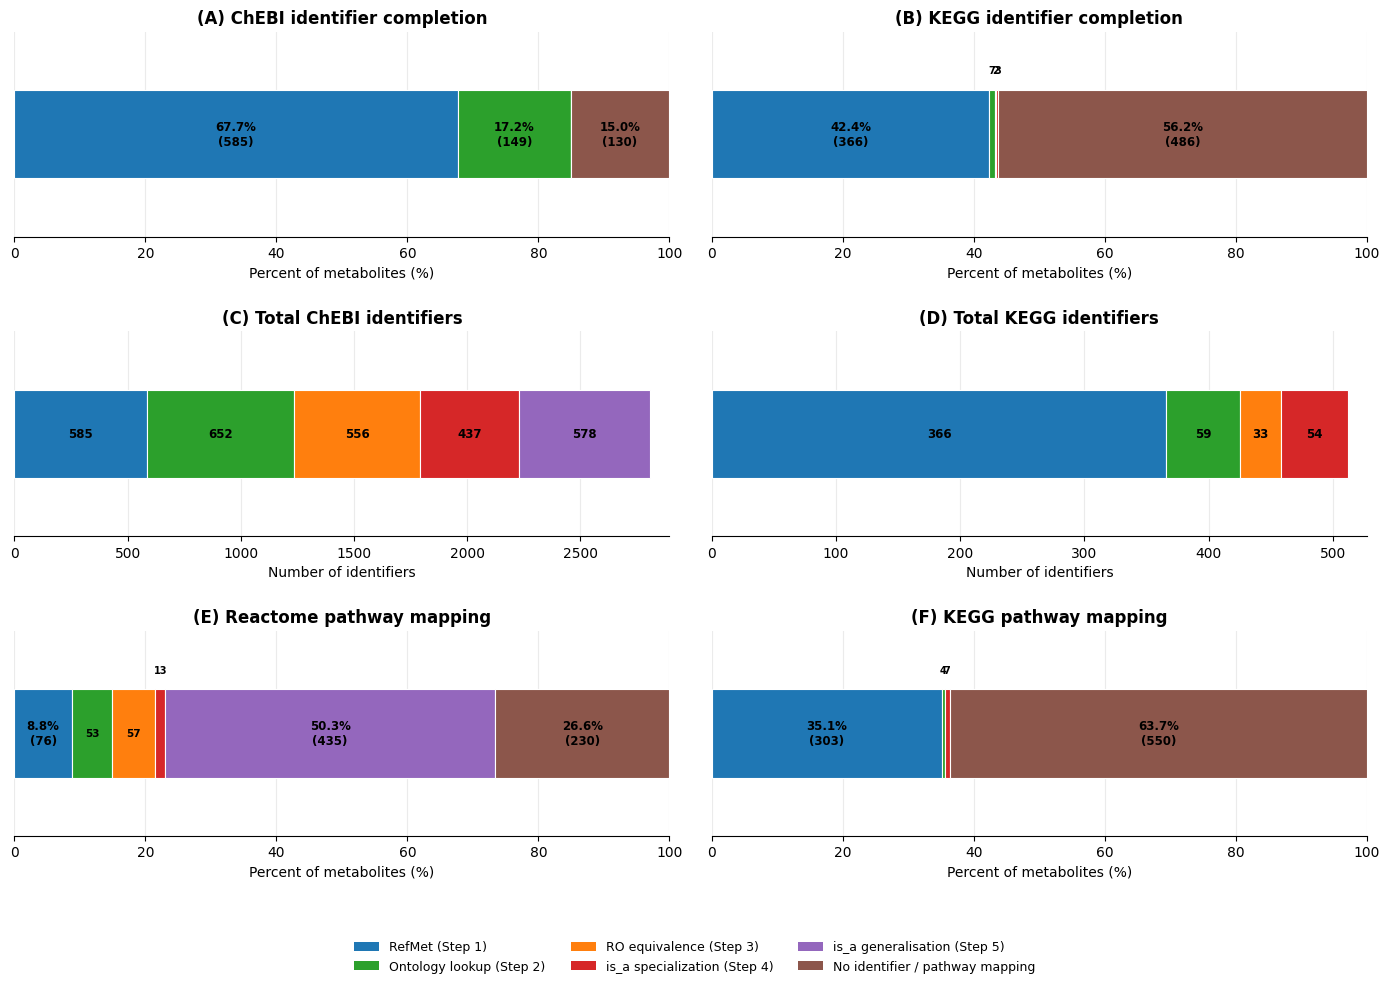

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


# =========================================================
# Prepare tables
# =========================================================

counts_plot = mapping_counts.set_index("Stage").copy()
percentages_plot = mapping_percentages.set_index("Stage").copy()

n_metabolites = len(df_step5)


# =========================================================
# Colours
# =========================================================

STEP_COLORS = {
    "Step 1": "#1f77b4",       # blue
    "Step 2": "#2ca02c",       # green
    "Step 3": "#ff7f0e",       # orange
    "Step 4": "#d62728",       # red
    "Step 5": "#9467bd",       # purple
    "No mapping": "#8c564b",   # brown
}

STEP_LABELS = {
    "Step 1": "RefMet (Step 1)",
    "Step 2": "Ontology lookup (Step 2)",
    "Step 3": "RO equivalence (Step 3)",
    "Step 4": "is_a specialization (Step 4)",
    "Step 5": "is_a generalisation (Step 5)",
    "No mapping": "No identifier / pathway mapping",
}


# =========================================================
# Convert cumulative metabolite counts to incremental counts
# =========================================================

def cumulative_to_incremental(
    count_column,
    percentage_column,
    stages,
):
    """
    Convert cumulative metabolite-level results into the
    additional contribution of each Step.

    The final 'No mapping' segment completes the bar to 100%.
    """

    cumulative_counts = (
        counts_plot
        .loc[stages, count_column]
        .astype(float)
    )

    cumulative_percentages = (
        percentages_plot
        .loc[stages, percentage_column]
        .astype(float)
    )

    incremental_counts = cumulative_counts.diff()
    incremental_counts.iloc[0] = cumulative_counts.iloc[0]

    incremental_percentages = cumulative_percentages.diff()
    incremental_percentages.iloc[0] = cumulative_percentages.iloc[0]

    # Prevent tiny negative values caused by rounding
    incremental_counts = incremental_counts.clip(lower=0)
    incremental_percentages = incremental_percentages.clip(lower=0)

    final_count = int(round(cumulative_counts.iloc[-1]))
    final_percentage = float(cumulative_percentages.iloc[-1])

    no_mapping_count = max(0, n_metabolites - final_count)
    no_mapping_percentage = max(0.0, 100.0 - final_percentage)

    result = pd.DataFrame({
        "Category": stages + ["No mapping"],
        "Count": (
            incremental_counts.round().astype(int).tolist()
            + [no_mapping_count]
        ),
        "Percent": (
            incremental_percentages.tolist()
            + [no_mapping_percentage]
        ),
    })

    assert result["Count"].sum() == n_metabolites

    assert np.isclose(
        result["Percent"].sum(),
        100.0,
        atol=0.15,
    )

    return result


# =========================================================
# Prepare completion and pathway mapping data
# =========================================================

chebi_identifier_data = cumulative_to_incremental(
    count_column="Metabolites with ChEBI identifiers",
    percentage_column="ChEBI identifier completion (%)",
    stages=[
        "Step 1",
        "Step 2",
        "Step 3",
        "Step 4",
    ],
)

kegg_identifier_data = cumulative_to_incremental(
    count_column="Metabolites with KEGG identifiers",
    percentage_column="KEGG identifier completion (%)",
    stages=[
        "Step 1",
        "Step 2",
        "Step 3",
        "Step 4",
    ],
)

# =========================================================
# Reactome pathway mapping
#
# Steps 1–4 are cumulative.
# Step 5 is already an independent new contribution.
# =========================================================

reactome_steps_1_to_4 = cumulative_to_incremental(
    count_column="Metabolites mapped to Reactome pathways",
    percentage_column="Reactome pathway mapping (%)",
    stages=[
        "Step 1",
        "Step 2",
        "Step 3",
        "Step 4",
    ],
)


# Remove the temporary No mapping row.
# We will recalculate it after adding Step 5.
reactome_pathway_data = (
    reactome_steps_1_to_4
    .loc[
        reactome_steps_1_to_4["Category"] != "No mapping"
    ]
    .copy()
)


# Step 5 already contains only its new Reactome contribution
step5_reactome_count = int(
    counts_plot.loc[
        "Step 5",
        "Metabolites mapped to Reactome pathways",
    ]
)

step5_reactome_percent = float(
    percentages_plot.loc[
        "Step 5",
        "Reactome pathway mapping (%)",
    ]
)


reactome_pathway_data = pd.concat(
    [
        reactome_pathway_data,
        pd.DataFrame({
            "Category": ["Step 5"],
            "Count": [step5_reactome_count],
            "Percent": [step5_reactome_percent],
        }),
    ],
    ignore_index=True,
)


# Final unmapped metabolites after Steps 1–5
n_reactome_mapped = int(
    reactome_pathway_data["Count"].sum()
)

reactome_no_mapping_count = (
    n_metabolites - n_reactome_mapped
)

reactome_no_mapping_percent = (
    100
    * reactome_no_mapping_count
    / n_metabolites
)


reactome_pathway_data = pd.concat(
    [
        reactome_pathway_data,
        pd.DataFrame({
            "Category": ["No mapping"],
            "Count": [reactome_no_mapping_count],
            "Percent": [reactome_no_mapping_percent],
        }),
    ],
    ignore_index=True,
)


# Checks
assert reactome_pathway_data["Count"].sum() == n_metabolites

assert np.isclose(
    reactome_pathway_data["Percent"].sum(),
    100.0,
    atol=0.15,
)

kegg_pathway_data = cumulative_to_incremental(
    count_column="Metabolites mapped to KEGG pathways",
    percentage_column="KEGG pathway mapping (%)",
    stages=[
        "Step 1",
        "Step 2",
        "Step 3",
        "Step 4",
    ],
)


# =========================================================
# Prepare total identifier data
#
# Steps 1–4 are cumulative and are converted to incremental
# contributions. Step 5 is an independent generalisation
# output and is added directly.
# =========================================================

identifier_steps_1_to_4 = [
    "Step 1",
    "Step 2",
    "Step 3",
    "Step 4",
]


def cumulative_identifier_totals_to_incremental(
    total_column,
    stages,
):
    cumulative_values = (
        counts_plot
        .loc[stages, total_column]
        .astype(float)
    )

    incremental_values = cumulative_values.diff()
    incremental_values.iloc[0] = cumulative_values.iloc[0]

    if (incremental_values < 0).any():
        raise ValueError(
            f"{total_column} is not cumulative across {stages}."
        )

    return pd.DataFrame({
        "Category": stages,
        "Count": incremental_values.round().astype(int).tolist(),
    })


# ChEBI: Steps 1–4 incremental
chebi_total_identifier_data = (
    cumulative_identifier_totals_to_incremental(
        total_column="Total ChEBI identifiers",
        stages=identifier_steps_1_to_4,
    )
)

# Step 5 ChEBI generalisations are independent
step5_total_chebi = int(
    counts_plot.loc["Step 5", "Total ChEBI identifiers"]
)

chebi_total_identifier_data = pd.concat(
    [
        chebi_total_identifier_data,
        pd.DataFrame({
            "Category": ["Step 5"],
            "Count": [step5_total_chebi],
        }),
    ],
    ignore_index=True,
)


# KEGG: Steps 1–4 incremental, no Step 5
kegg_total_identifier_data = (
    cumulative_identifier_totals_to_incremental(
        total_column="Total KEGG identifiers",
        stages=identifier_steps_1_to_4,
    )
)

# =========================================================
# Plot one 100% stacked bar
# =========================================================

def plot_percentage_stacked_bar(
    ax,
    plot_data,
    title,
):
    left = 0.0

    for _, row in plot_data.iterrows():

        category = row["Category"]
        count = int(row["Count"])
        percent = float(row["Percent"])

        ax.barh(
            y=0,
            width=percent,
            left=left,
            height=0.56,
            color=STEP_COLORS[category],
            edgecolor="white",
            linewidth=0.8,
        )

        if percent >= 7:
            ax.text(
                left + percent / 2,
                0,
                f"{percent:.1f}%\n({count})",
                ha="center",
                va="center",
                fontsize=8.5,
                fontweight="bold",
            )

        elif percent >= 2:
            ax.text(
                left + percent / 2,
                0,
                f"{count}",
                ha="center",
                va="center",
                fontsize=7.5,
                fontweight="bold",
            )

        elif percent > 0:
            ax.text(
                left + percent / 2,
                0.37,
                f"{count}",
                ha="center",
                va="bottom",
                fontsize=7,
                fontweight="bold",
            )

        left += percent

    ax.set_xlim(0, 100)
    ax.set_ylim(-0.65, 0.65)
    ax.set_yticks([])

    ax.set_xlabel("Percent of metabolites (%)")
    ax.set_title(title, fontweight="bold")

    ax.grid(
        axis="x",
        alpha=0.25,
        linewidth=0.8,
    )

    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)


# =========================================================
# Plot total identifiers
# =========================================================

def plot_total_identifier_bar(
    ax,
    plot_data,
    title,
):
    """
    Plot one stacked bar of absolute identifier counts.

    The bar does not represent 100% and does not contain
    a 'No mapping' segment.
    """

    left = 0

    for _, row in plot_data.iterrows():

        category = row["Category"]
        count = int(row["Count"])

        ax.barh(
            y=0,
            width=count,
            left=left,
            height=0.56,
            color=STEP_COLORS[category],
            edgecolor="white",
            linewidth=0.8,
        )

        # Label inside sufficiently large segments
        if count >= 0.06 * plot_data["Count"].sum():
            ax.text(
                left + count / 2,
                0,
                f"{count}",
                ha="center",
                va="center",
                fontsize=8.5,
                fontweight="bold",
            )

        # Label above smaller segments
        elif count > 0:
            ax.text(
                left + count / 2,
                0.37,
                f"{count}",
                ha="center",
                va="bottom",
                fontsize=7,
                fontweight="bold",
            )

        left += count

    total_width = int(plot_data["Count"].sum())

    ax.set_xlim(
        0,
        total_width * 1.03,
    )

    ax.set_ylim(-0.65, 0.65)
    ax.set_yticks([])

    ax.set_xlabel("Number of identifiers")
    ax.set_title(title, fontweight="bold")

    ax.grid(
        axis="x",
        alpha=0.25,
        linewidth=0.8,
    )

    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)


# =========================================================
# Create 3 × 2 figure
# =========================================================

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(14, 10),
)


# Row 1: Identifier completion
plot_percentage_stacked_bar(
    ax=axes[0, 0],
    plot_data=chebi_identifier_data,
    title="(A) ChEBI identifier completion",
)

plot_percentage_stacked_bar(
    ax=axes[0, 1],
    plot_data=kegg_identifier_data,
    title="(B) KEGG identifier completion",
)


# Row 2: Total identifiers
plot_total_identifier_bar(
    ax=axes[1, 0],
    plot_data=chebi_total_identifier_data,
    title="(C) Total ChEBI identifiers",
)

plot_total_identifier_bar(
    ax=axes[1, 1],
    plot_data=kegg_total_identifier_data,
    title="(D) Total KEGG identifiers",
)


# Row 3: Pathway mapping
plot_percentage_stacked_bar(
    ax=axes[2, 0],
    plot_data=reactome_pathway_data,
    title="(E) Reactome pathway mapping",
)

plot_percentage_stacked_bar(
    ax=axes[2, 1],
    plot_data=kegg_pathway_data,
    title="(F) KEGG pathway mapping",
)


# =========================================================
# Shared legend
# =========================================================

legend_order = [
    "Step 1",
    "Step 2",
    "Step 3",
    "Step 4",
    "Step 5",
    "No mapping",
]

legend_handles = [
    Patch(
        facecolor=STEP_COLORS[category],
        label=STEP_LABELS[category],
    )
    for category in legend_order
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=3,
    frameon=False,
    fontsize=9,
)

fig.tight_layout(
    rect=[0, 0.10, 1, 1],
    h_pad=2.1,
    w_pad=1.8,
)


# =========================================================
# Export
# =========================================================

plt.savefig(
    OUTDIR / "mapping_summary_six_panels.png",
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    OUTDIR / "mapping_summary_six_panels.pdf",
    bbox_inches="tight",
)

plt.show()

## What to do next

Use `step5_generalisation.tsv` as the final harmonised mapping table. For enrichment analysis continue with **Tutorial 2 — ORA with ChemEquivMapper**. For multi-assay studies first use **Tutorial 3 — Merging assays**.
